# Week 4: 데이터 분석 심화 (2026-04-22)

## 1. 오늘의 학습 목표
- 단변량 분석
- 이변량 분석

---

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False



## 2. 실습 진행
### 단변량 분석

In [5]:
titanic = pd.read_csv('content/titanic_train.csv')
air = pd.read_csv('content/airquality2.csv')

1. 평균 (Arithmetic Mean, $\bar{x}$)
- 정의: 모든 데이터 값을 더한 후 데이터 개수로 나눈 값.
- 특징: 데이터의 '무게 중심' 역할을 하지만, 이상치(Outlier)에 매우 취약합니다.
- Pandas: `df['column'].mean()`
2. 중앙값 (Median)
- 정의: 데이터를 크기 순으로 정렬했을 때 정중앙에 위치한 값.
- 특징: 평균과 달리 이상치에 강건(Robust)합니다. 소득 수준처럼 극단적인 값이 있는 데이터를 볼 때 평균보다 더 현실적인 지표가 됩니다.
- Pandas: `df['column'].median()`
3. 최빈값 (Mode)
- 정의: 데이터 집합에서 가장 자주 등장하는 값.
- 특징: 주로 범주형(Categorical) 데이터(성별, 혈액형 등)의 대표값을 구할 때 사용합니다.
- Pandas: `df['column'].mode()` (결과가 여러 개일 수 있어 Series 형태로 반환됨)
4. 4분위수 (Quartile)
- 정의: 데이터를 4등분했을 때 각 지점의 값 ($Q1(25%)$, $Q2(50%=중앙값)$, $Q3(75%)$).
- 특징: 데이터가 어디에 얼마나 몰려 있는지 파악하기 좋습니다. 특히 $Q1$과 $Q3$ 사이의 거리인 **IQR(Interquartile Range)**은 이상치를 판단하는 기준이 됩니다.
- Pandas: `df['column'].quantile([0.25, 0.5, 0.75])`

💡 Senior Mentor's Tip
분석을 시작할 때 평균과 중앙값의 차이를 먼저 확인해 보세요.

- 평균 > 중앙값: 데이터가 오른쪽으로 꼬리가 긴 분포(Right-skewed)이며, 매우 큰 이상치가 존재할 가능성이 높습니다.
- 평균 $\approx$ 중앙값: 데이터가 비교적 대칭적인 분포를 이루고 있음을 시사합니다.

평균 요금: 32.20
요금 중앙값: 14.45
최빈 요금: 8.05
4분위수:
0.25     7.9104
0.50    14.4542
0.75    31.0000
Name: Fare, dtype: float64


<Axes: xlabel='Fare'>

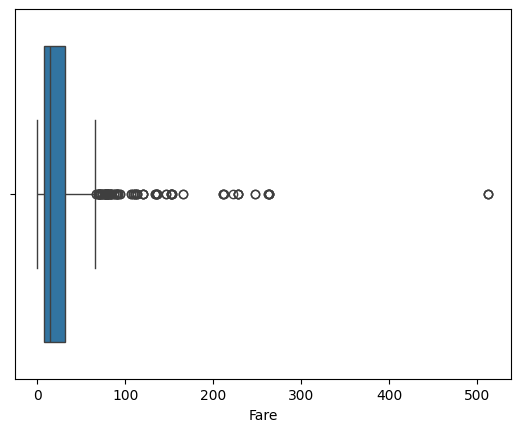

In [6]:
# 타이타닉 요금(Fare) 데이터로 기초 통계량 확인
print(f"평균 요금: {titanic['Fare'].mean():.2f}")
print(f"요금 중앙값: {titanic['Fare'].median():.2f}")
print(f"최빈 요금: {titanic['Fare'].mode()[0]:.2f}")
print(f"4분위수:\n{titanic['Fare'].quantile([0.25, 0.5, 0.75])}")

# 시각적으로 확인 (Boxplot은 4분위수를 시각화한 대표적인 그래프입니다)
sns.boxplot(x=titanic['Fare'])


히스토그램은 데이터의 **분포(Distribution)**를 시각화하는 가장 강력한 도구 중 하나입니다. 말씀하신 대로 bins 설정과 결과값의 구조를 이해하면 시각화를 넘어 정량적인 데이터 분석이 가능해집니다.

1. bins에 따른 차이: 정보의 밀도 결정
bins는 데이터를 나누는 **'바구니의 개수'**입니다. 이 값을 어떻게 설정하느냐에 따라 데이터의 해석이 달라집니다.

- bins가 너무 적을 때 (Underfitting): 데이터의 세부적인 특징이 뭉개져서 전체적인 흐름만 보입니다. 중요한 변곡점을 놓칠 수 있습니다.
- bins가 너무 많을 때 (Overfitting): 데이터의 노이즈(먼지)까지 다 보여주게 되어, 오히려 데이터의 본질적인 패턴을 파악하기 힘들어집니다.
- Tip: 보통 데이터 개수의 제곱근($\sqrt{n}$)이나 Sturges' Rule 등을 참고하지만, 실무에서는 여러 값을 넣어보며 **'데이터의 특징이 가장 잘 드러나는 구간'**을 찾는 감각이 필요합니다.

2. 결과 저장 및 데이터 확인 (구간 값과 개수): Matplotlib의 plt.hist() 함수는 그래프를 그리는 동시에 분석에 필요한 핵심 데이터를 반환합니다.

1. 빈도수 (Counts): [30. 14. 10. 14.  3. 29. 39. 65. 73. 42. 65. 62. 33. 47. 38. 21. 28. 21.
 16. 14. 15.  7.  9.  8.  4.  0.  5.  1.  0.  1.]
2. 구간 경계값 (Edges): [ 0.42        3.07266667  5.72533333  8.378      11.03066667 13.68333333
 16.336      18.98866667 21.64133333 24.294      26.94666667 29.59933333
 32.252      34.90466667 37.55733333 40.21       42.86266667 45.51533333
 48.168      50.82066667 53.47333333 56.126      58.77866667 61.43133333
 64.084      66.73666667 69.38933333 72.042      74.69466667 77.34733333
 80.        ]


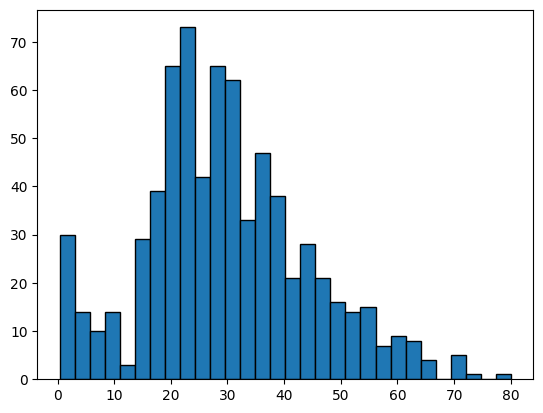

In [26]:
# 히스토그램 생성 및 결과 저장
# n: 빈도수 (Counts)
# bins: 구간 경계값 (Edges)
# patches: 그래프를 구성하는 도형 객체 리스트 (보통 무시)
n, bins, patches = plt.hist(titanic['Age'].dropna(), bins=30, edgecolor='black')
print("1. 빈도수 (Counts):", n)
print("2. 구간 경계값 (Edges):", bins)

구간: 0.00 ~ 34.16 | 빈도수: 687
구간: 34.16 ~ 68.31 | 빈도수: 90
구간: 68.31 ~ 102.47 | 빈도수: 61
구간: 102.47 ~ 136.62 | 빈도수: 22
구간: 136.62 ~ 170.78 | 빈도수: 11
구간: 170.78 ~ 204.93 | 빈도수: 0
구간: 204.93 ~ 239.09 | 빈도수: 9
구간: 239.09 ~ 273.24 | 빈도수: 8
구간: 273.24 ~ 307.40 | 빈도수: 0
구간: 307.40 ~ 341.55 | 빈도수: 0
구간: 341.55 ~ 375.71 | 빈도수: 0
구간: 375.71 ~ 409.86 | 빈도수: 0
구간: 409.86 ~ 444.02 | 빈도수: 0
구간: 444.02 ~ 478.17 | 빈도수: 0
구간: 478.17 ~ 512.33 | 빈도수: 3


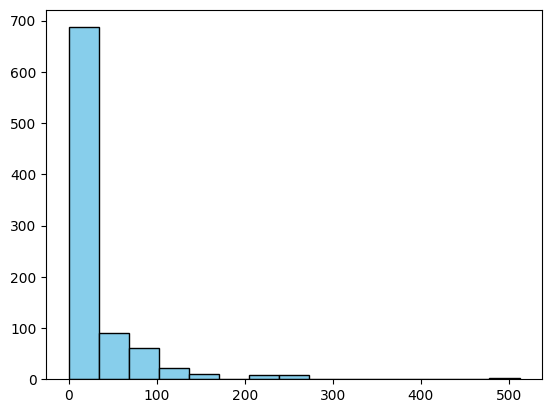

In [38]:
# 결과를 변수에 담아 분석하기
hist_data = plt.hist(titanic['Fare'], bins=15, color='skyblue', edgecolor='black')

counts = hist_data[0] # 빈도수
edges = hist_data[1]  # 경계값

for i in range(len(counts)):
    print(f"구간: {edges[i]:.2f} ~ {edges[i+1]:.2f} | 빈도수: {int(counts[i])}")


1. 히스토그램의 한계: '계단 현상'과 '경계의 모호성'
히스토그램은 데이터를 **불연속적인 칸**에 강제로 집어넣습니다. 이 과정에서 두 가지 문제가 발생합니다.
- **불연속성**: 실제 데이터는 연속적임에도 불구하고, 그래프는 뚝뚝 끊기는 계단 모양으로 보입니다.
- **빈 너비의 민감도**: 동일한 데이터라도 `bins=10`일 때와 `bins=11`일 때의 모양이 크게 다를 수 있습니다. 이는 분석가가 의도치 않게 데이터를 왜곡해서 해석할 위험을 초래합니다.

---

2. KDE (Kernel Density Estimation, 커널 밀도 추정)
KDE는 히스토그램의 단점을 극복하기 위해 **'개별 데이터 포인트를 부드러운 곡선(Kernel)으로 바꾼 뒤 모두 더하는 방식'**을 사용합니다.

- **작동 원리**: 각 데이터 포인트마다 작은 '언덕(주로 정규분포 모양)'을 쌓고, 이 언덕들을 모두 합쳐서 하나의 매끄러운 곡선을 만듭니다.
- **장점**:
    - **연속성**: 데이터의 흐름을 부드러운 곡선으로 표현하여 전체적인 분포의 특징(봉우리의 개수, 대칭성 등)을 파악하기 쉽습니다.
    - **강건함(Robustness)**: 특정 구간 경계에 민감하게 반응하지 않으므로, 데이터의 본질적인 형태를 더 안정적으로 보여줍니다.

---

💡 Senior Mentor's Tip
실무에서는 **히스토그램과 KDE를 겹쳐서 보는 것**이 정석입니다.
- **히스토그램**: 실제 데이터가 어느 구간에 몇 개 있는지 '사실(Fact)'을 확인하는 용도.
- **KDE**: 데이터가 어떤 확률적인 구조를 가지고 있는지 '패턴(Pattern)'을 추정하는 용도.

만약 KDE 곡선이 너무 삐죽삐죽하거나 너무 뭉툭하다면, `bw_adjust`(bandwidth) 옵션을 조절하여 부드러운 정도를 제어할 수 있습니다. (히스토그램의 `bins`와 유사한 역할을 하지만 훨씬 유연합니다.)

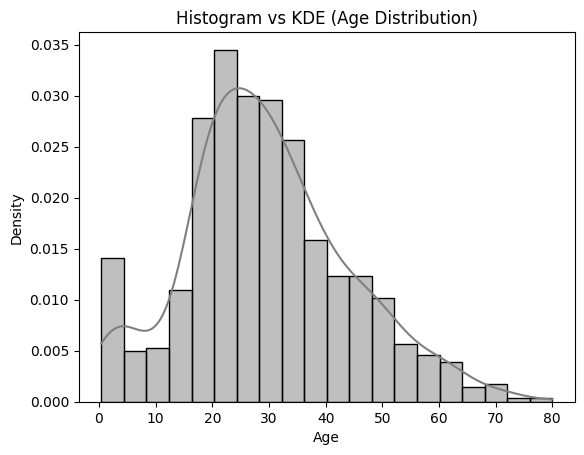

In [36]:
# 히스토그램과 KDE를 동시에 그리기
# hist=True, kde=True 설정을 통해 비교 (최신 버전은 sns.histplot 사용 권장)
sns.histplot(titanic['Age'].dropna(), bins=20, 
kde=True,
 color='gray', stat='density')

plt.title('Histogram vs KDE (Age Distribution)')
plt.show()

1. 관측 데이터 (180일간의 기록)
우리가 가진 180개의 데이터 포인트는 사실 전체 시간(과거와 미래를 포함한 무한한 시간) 중 아주 일부인 **표본**일 뿐입니다. 히스토그램은 이 180일 동안 '무슨 일이 있었는지'를 보여주는 **경험적 분포(Empirical Distribution)**입니다.

2. 밀도 추정 (KDE의 역할)
히스토그램의 칸(bin)을 채우고 곡선을 그리는(KDE) 행위는, "데이터가 없던 구간(예: 1350명과 1400명 사이)에서도 방문자가 발생한다면 어떤 확률일까?"라는 질문에 답하기 위해 **빈 공간을 수학적으로 메우는 작업**입니다.
- 결과적으로 매끄러운 곡선이 만들어지며, 이 곡선 아래의 **전체 면적은 1(100%)**이 됩니다.

3. 확률로 나타내기 (의사결정)
이제 추정된 밀도 함수를 통해 다음과 같은 확률적 예측이 가능해집니다.
- "내일 방문자가 1500명 이상일 확률은?" $\rightarrow$ 곡선에서 1500 이상의 면적을 계산.
- "서버가 버티려면 상위 5% 수준인 2000명까지 대비해야 할까?" $\rightarrow$ 상위 5%에 해당하는 방문자 수 지점 파악.

---

💡 Senior Mentor's Insight: 왜 '개수'가 아니라 '밀도'인가?
사용자의 예시에서 방문자 수는 1200명, 1201명처럼 끊어지는 값(이산형)이지만, 만약 '방문자가 머문 시간'처럼 무한히 쪼개지는 값(연속형)이라면 **"정확히 10.5분 머물 확률"은 0**에 가깝습니다. (10.500001분일 수도 있으니까요.)

그래서 우리는 **특정 지점의 값** 대신, **특정 구간의 면적(밀도)**을 통해 확률을 이야기하게 됩니다. 이것이 히스토그램의 `y축(개수)`이 KDE에서는 `Density(밀도)`로 변하는 이유입니다.

---

💻 실습 팁
방문자 수 예시처럼 특정 구간의 확률을 계산해보고 싶다면, Pandas의 `rank(pct=True)`를 쓰거나 `scipy.stats` 라이브러리를 활용해 추정된 분포에서 확률값을 직접 뽑아낼 수도 있습니다. 나중에 필요하시면 코드를 짜 드릴게요!_


박스플롯(Boxplot)은 데이터의 통계적 요약 정보를 한눈에 보여주는 가장 효율적인 그래프입니다. 특히 **이상치(Outlier)를 식별**하고 **여러 그룹 간의 분포를 비교**할 때 필수적입니다.

박스플롯의 구조와 말씀하신 **IQR, Min, Max**의 관계를 정리해 드릴게요.

---

1. 박스플롯의 5대 지표 (Five-Number Summary)
박스플롯은 데이터를 크기 순으로 정렬했을 때 다음 5가지 지점을 시각화합니다.
1. **최솟값 (Minimum)**: 하단 수염의 끝
2. **제1사분위수 (Q1)**: 박스의 밑면 (하위 25% 지점)
3. **중앙값 (Q2/Median)**: 박스 안의 가로선 (하위 50% 지점)
4. **제3사분위수 (Q3)**: 박스의 윗면 (하위 75% 지점)
5. **최대값 (Maximum)**: 상단 수염의 끝

---

2. IQR (Interquartile Range, 사분위수 범위)
- **계산식**: $IQR = Q3 - Q1$
- **의미**: 전체 데이터 중 **가운데 50%**가 모여 있는 구간의 길이입니다. 
- **역할**: 박스플롯에서 수염(Whisker)의 길이를 결정하고, 이상치를 판단하는 **기준점**이 됩니다.

---

3. 수염(Whisker)과 실제 Min/Max
박스플롯에서 수염은 단순히 데이터의 진짜 최솟값/최대값까지 뻗어나가는 것이 아닙니다. 일반적으로 **Tukey의 기준**을 따릅니다.

- **상단 경계선 (Upper Fence)**: $Q3 + (1.5 \times IQR)$
- **하단 경계선 (Lower Fence)**: $Q1 - (1.5 \times IQR)$
- **진짜 수염의 끝**: 위 계산된 경계선 안쪽에 있는 **실제 데이터 중 가장 큰 값과 가장 작은 값**에서 멈춥니다.
- **이상치 (Outliers)**: 이 경계선(Fence)을 벗어난 데이터들은 점(dot)으로 따로 표시됩니다.

---

💡 Senior Mentor's Tip
박스플롯을 볼 때 **박스의 길이(IQR)**와 **수염의 대칭성**을 유심히 보세요.
- 박스가 위아래로 길면 데이터가 퍼져 있는 것이고, 짧으면 중앙에 밀집된 것입니다.
- 중앙값이 박스의 정중앙에 있지 않고 한쪽으로 치우쳐 있다면, 데이터가 **왜도(Skewness)**를 가지고 있음을 알 수 있습니다. 히스토그램을 그리기 전에 데이터의 대략적인 '상태'를 파악하기 아주 좋은 도구입니다.

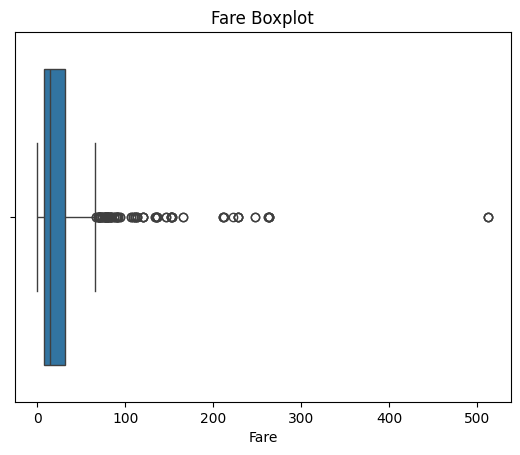

Q1: 7.91, Q3: 31.00, IQR: 23.09
이상치 경계선: -26.72 ~ 65.63


In [39]:
### 💻 실습 코드로 확인하기

# 1. 시각화
sns.boxplot(x=titanic['Fare'])
plt.title('Fare Boxplot')
plt.show()

# 2. 수치로 확인
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"이상치 경계선: {lower_fence:.2f} ~ {upper_fence:.2f}")

1. 빈도수 확인: `.value_counts()`
사용자께서 말씀하신 것처럼 범주가 많아질수록 개별적으로 `count()`를 하는 것은 불가능에 가깝습니다. `value_counts()`는 범주의 개수와 상관없이 자동으로 그룹화하여 빈도수를 내림차순으로 정렬해 줍니다.

2. 비율 확인: `normalize=True` (핵심 팁!)
전체 건수로 나누는 수식을 직접 입력할 수도 있지만, Pandas에서는 파라미터 하나로 비율을 바로 구할 수 있습니다.

- **왜 이 방식을 쓸까요?**: 코드가 간결해지고, 나중에 데이터가 필터링되어 전체 개수가 변하더라도 항상 정확한 비율을 계산해 줍니다.

3. 범주의 가짓수 확인: `nunique()`
본격적인 분석 전에 "이 컬럼에 범주가 총 몇 종류나 있지?"를 알고 싶을 때 유용합니다.
- `unique()`: 범주의 종류를 배열로 반환
- `nunique()`: 범주의 종류가 총 몇 개인지 숫자로 반환

---

💻 시각화와 연결하기
범주형 데이터는 숫자로 보는 것보다 **막대 그래프(Bar Chart)**로 볼 때 그 차이가 명확히 느껴집니다.

💡 Senior Mentor's Tip
범주형 데이터를 분석할 때 꼭 체크해야 할 포인트가 있습니다. 바로 **결측치(NaN)**입니다.
- `value_counts()`는 기본적으로 결측치를 제외하고 계산합니다.
- **`dropna=False`** 옵션을 추가하면 데이터에서 누락된 범주가 얼마나 되는지도 함께 확인할 수 있어 데이터 품질 체크에 매우 유용합니다.

이처럼 범주형 변수는 **[빈도수 확인 $\rightarrow$ 비율 확인 $\rightarrow$ 결측치 체크]** 순서로 진행하는 것이 정석입니다._

예: 타이타닉의 객실 등급(Pclass)별 빈도수 Pclass
3    491
1    216
2    184
Name: count, dtype: int64
전체 합이 1(100%)이 되도록 비율로 반환 Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
결측치 포함하여 확인 Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


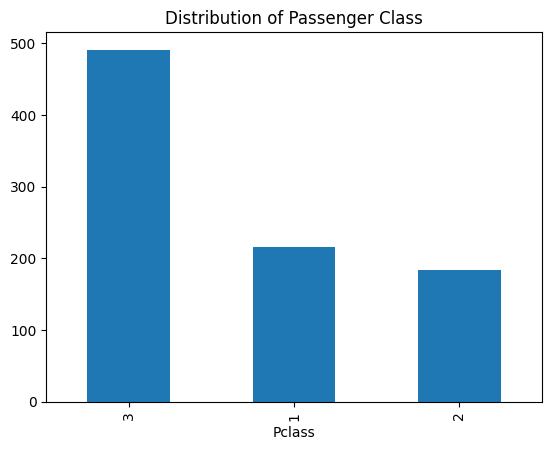

In [ ]:
print('예: 타이타닉의 객실 등급(Pclass)별 빈도수',titanic['Pclass'].value_counts())
print('전체 합이 1(100%)이 되도록 비율로 반환', titanic['Pclass'].value_counts(normalize=True))
print('결측치 포함하여 확인', titanic['Embarked'].value_counts(dropna=False))

# 빈도수를 막대 그래프로 시각화
titanic['Pclass'].value_counts().plot(kind='bar')
plt.title('Distribution of Passenger Class')
plt.show()


연습문제
**보스톤 집값 데이터 변수설명**
* medv  : 1978 보스턴 주택 가격, 506개 타운의 주택 가격 중앙값 (단위 1,000 달러) <== Target
* crim	범죄율
* zn	25,000 평방피트를 초과 거주지역 비율
* indus	비소매상업지역 면적 비율
* chas	찰스강변 위치(범주 : 강변1, 아니면 0)
* nox	일산화질소 농도
* rm	주택당 방 수
* age	1940년 이전에 건축된 주택의 비율
* dis	직업센터의 거리
* rad	방사형 고속도로까지의 거리
* tax	재산세율
* ptratio	학생/교사 비율
* lstat	인구 중 하위 계층 비율


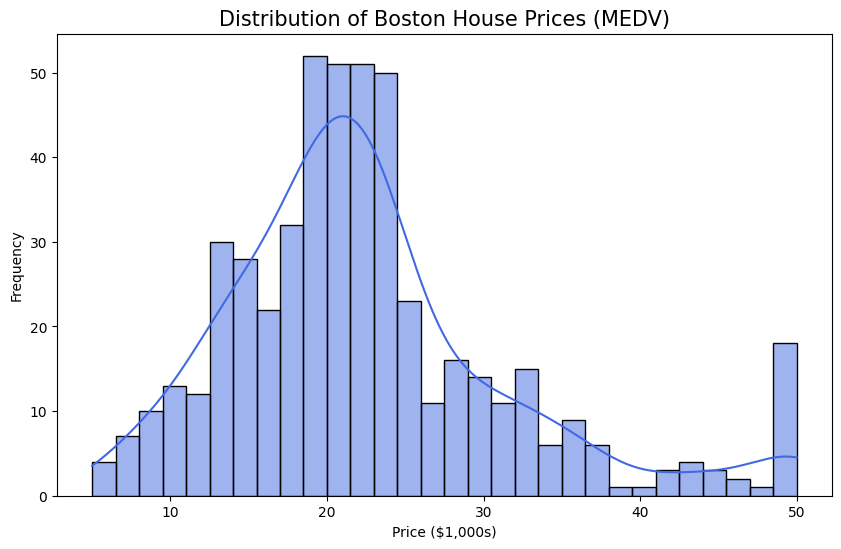

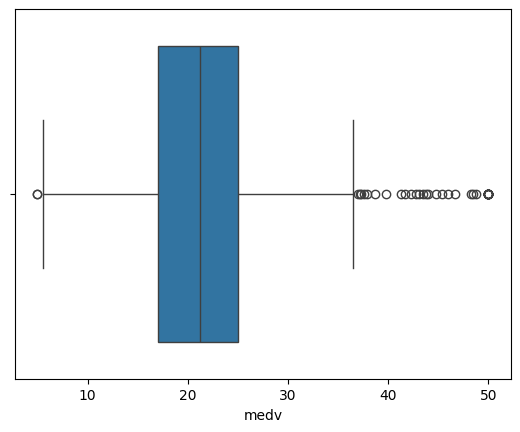

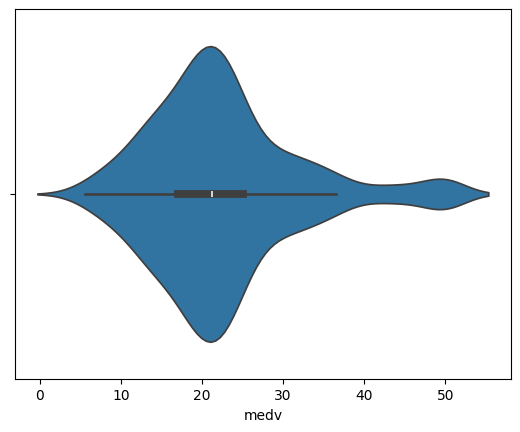

In [ ]:
boston = pd.read_csv('content/boston.csv')

#숫자형 변수
# 캔버스 설정
plt.figure(figsize=(10, 6))
# 히스토그램과 밀도곡선 함께 그리기
sns.histplot(boston['medv'], kde=True, color='royalblue', bins=30)
# 가독성을 위한 레이블링
plt.title('Distribution of Boston House Prices (MEDV)', fontsize=15)
plt.xlabel('Price ($1,000s)')
plt.ylabel('Frequency')
plt.show()
sns.boxplot(x=boston['medv'])
plt.show()
sns.violinplot(x=boston['medv'])
plt.show()

/tmp/ipykernel_33189/3909435366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='chas', data=boston, palette='viridis')


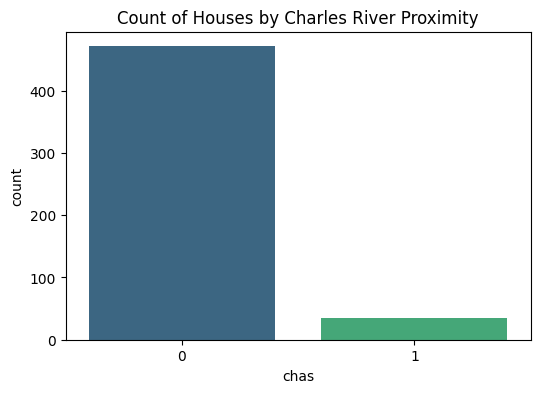

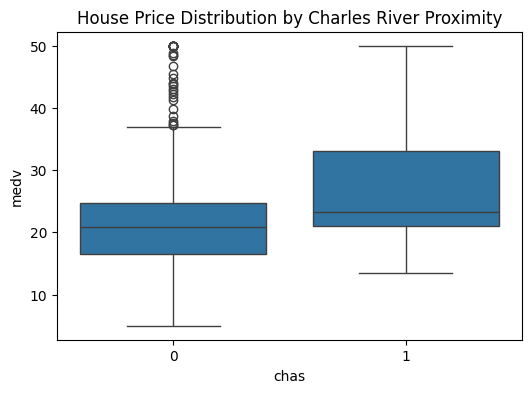

In [52]:
# 1. 빈도수 확인 (Count Plot)
plt.figure(figsize=(6, 4))
sns.countplot(x='chas', data=boston, palette='viridis')
plt.title('Count of Houses by Charles River Proximity')
plt.show()
# 2. 범주별 가격 차이 확인 (Box Plot)
plt.figure(figsize=(6, 4))
sns.boxplot(x='chas', y='medv', data=boston)
plt.title('House Price Distribution by Charles River Proximity')
plt.show()

**실습**
- 고객사는 카시트 전문 판매 회사입니다.
    - 최근, 매출 그래프가 조금씩 아래로 향하기 시작했습니다. 회사의 여러 부서에서는 다양한 원인을 제시했지만, 그 원인들이 정말 데이터에 기반한 것인지는 여전히 의문입니다.

    - 부서별 문제 진단:
        - 가격 경쟁력 약화: 경쟁사와의 가격 경쟁에서 밀리고 있음
        - 광고비 집행 비효율: 광고비는 쓰고 있지만, 정말 적절하게 집행되지 않음
        - 국내 시장 편중: 해외 시장 개척은 뒷전이고, 국내 시장에만 집중됨
        - 지역 구매력 미파악: 지역별 구매력과 특성을 제대로 분석하지 못하고 있음

- 이 문제를 해결하기 위해 DX 프로젝트 팀이 빌딩되었습니다.
    - 여러분은 이 팀에서 데이터 분석을 책임지는 DX 컨설턴트로 합류했습니다.
    - 드디어 갈고 닦은 실력을 발휘할 기회가 주어졌습니다.
    - 자, 이제 단변량 분석을 통해 비즈니스 인사이트를 도출해 봅시다!

count    400.000000
mean       7.496325
std        2.824115
min        0.000000
25%        5.390000
50%        7.490000
75%        9.320000
max       16.270000
Name: Sales, dtype: float64


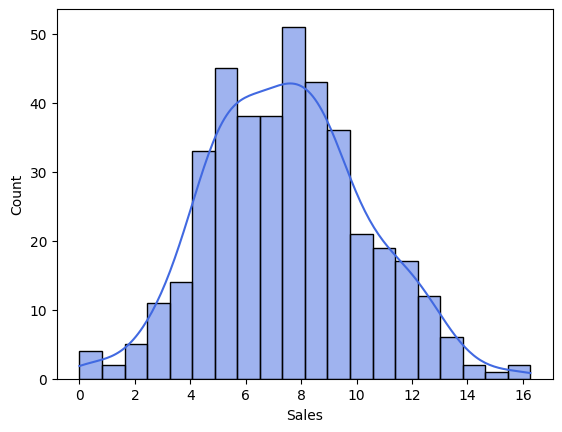

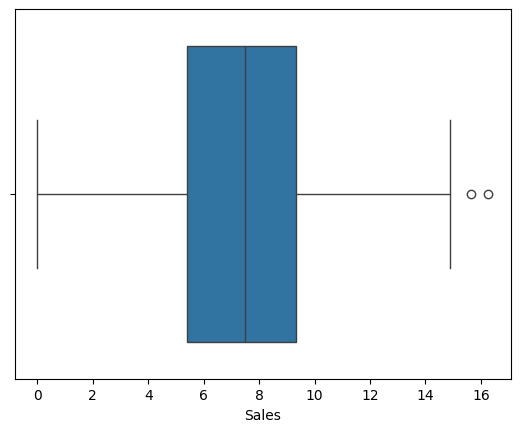

In [103]:
car = pd.read_csv('content/Carseats.csv')

print(car['Sales'].describe())

sns.histplot(car['Sales'], kde=True, color='royalblue', bins=20)
plt.show()
sns.boxplot(x=car['Sales'])
plt.show()

- 파악한 내용
    - 대부분의 매장은 6~8천개를 판매했다.

- 추가로 파악하면 좋을 것
    - 범주형 변수를 통해 유형 별 데이터 분석 필요
- 분석 보완
    - 기술적 검토: 현재 도출된 "6~8천 개"는 최빈값(Mode)이나 중앙값(Median) 부근의 관찰입니다. 더 객관적인 판단을 위해서는 왜도(Skewness) 수치를 확인해야 합니다. 만약 왜도가 0에 가깝다면 정규성을 가정할 수 있으나, 미세하게라도 한쪽으로 쏠려 있다면 평균값보다는 중앙값을 대표값으로 설정해야 분석의 오류가 적습니다.

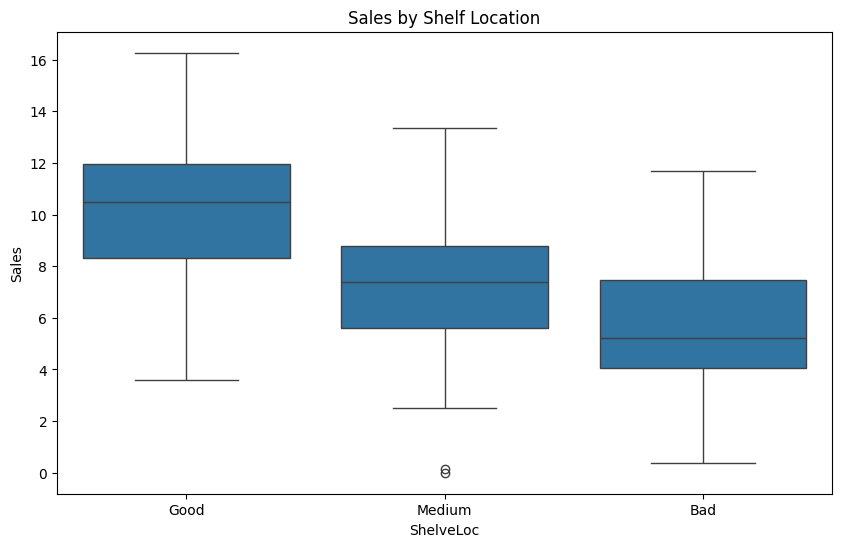

In [79]:
# 예: 진열 위치(ShelveLoc)에 따른 판매량(Sales)의 차이 분석
plt.figure(figsize=(10, 6))
sns.boxplot(x='ShelveLoc', y='Sales', data=car, order=['Good', 'Medium', 'Bad'])
plt.title('Sales by Shelf Location')
plt.show()


count    400.000000
mean     124.975000
std       15.334512
min       77.000000
25%      115.000000
50%      125.000000
75%      135.000000
max      175.000000
Name: CompPrice, dtype: float64


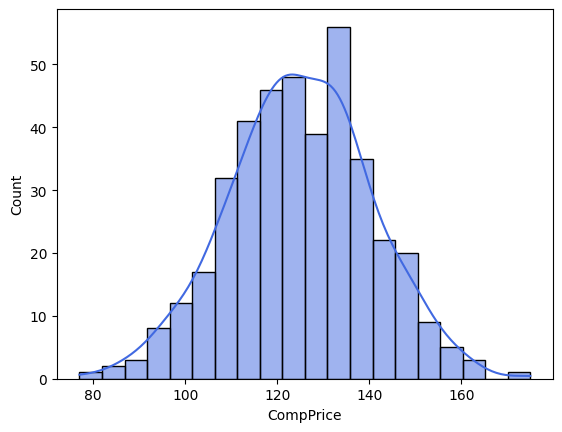

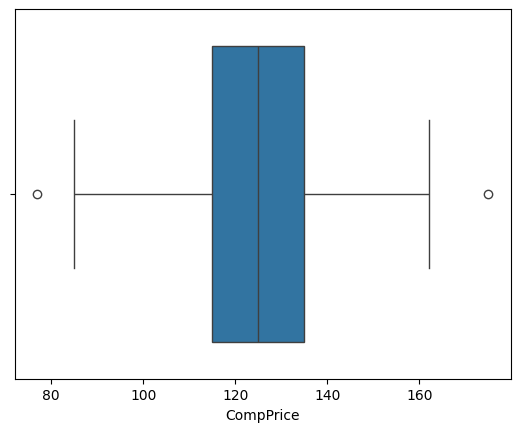

In [71]:
print(car['CompPrice'].describe())

sns.histplot(car['CompPrice'], kde=True, color='royalblue', bins=20)
plt.show()
sns.boxplot(x=car['CompPrice'])
plt.show()

- 파악한 내용
    - 경쟁사 가격은 115~135달러에 형성되어있다.

- 추가로 파악하면 좋을 것
    - 경쟁사 가격 대비 판매량을 분석해 실제로 경쟁사가 판매량에 영향을 미치는지 파악한다.
- 분석 보완
    - 분석의 한계: 경쟁사 가격 그 자체만으로는 비즈니스 통찰을 얻기 어렵습니다. 경쟁사 가격은 우리 제품 가격(Price) 결정의 '제약 조건'일 뿐입니다. 객관적인 경쟁력 파악을 위해서는 CompPrice와 Price의 **상관계수(Correlation Coefficient)**를 먼저 산출하여, 우리 회사가 시장 가격 추종 전략(Price Follower)을 쓰는지 독자적 가격 전략을 쓰는지 수치로 증명해야 합니다.

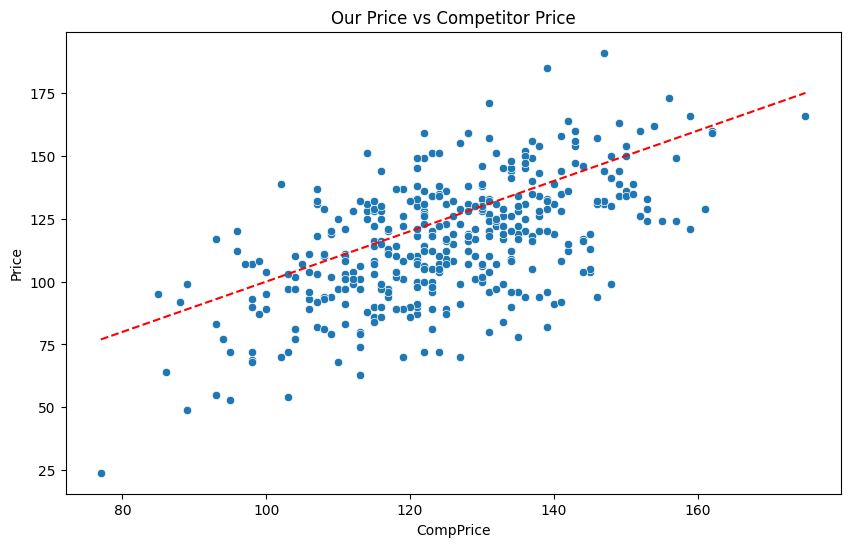

In [78]:
# 경쟁사 가격(CompPrice)과 우리 가격(Price)의 관계를 산점도로 확인
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CompPrice', y='Price', data=car)

# 기준선(우리 가격 = 경쟁사 가격) 추가
plt.plot([min(car['CompPrice']), max(car['CompPrice'])], 
         [min(car['CompPrice']), max(car['CompPrice'])], 
         color='red', linestyle='--')

plt.title('Our Price vs Competitor Price')
plt.show()


count    400.000000
mean      68.657500
std       27.986037
min       21.000000
25%       42.750000
50%       69.000000
75%       91.000000
max      120.000000
Name: Income, dtype: float64


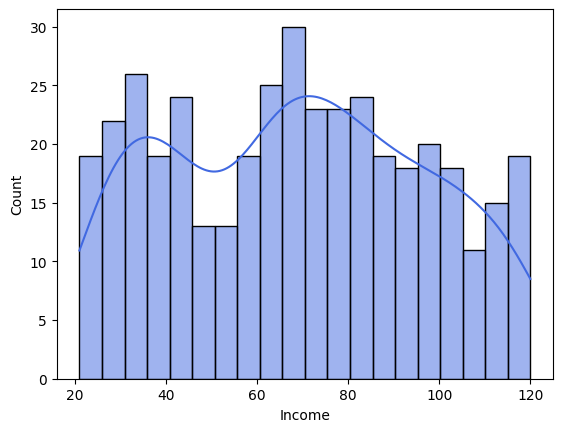

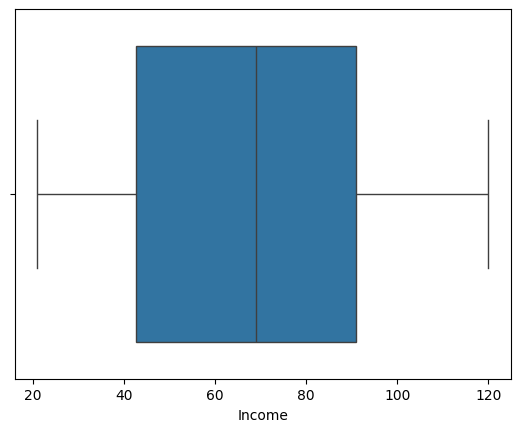

In [73]:
print(car['Income'].describe())

sns.histplot(car['Income'], kde=True, color='royalblue', bins=20)
plt.show()
sns.boxplot(x=car['Income'])
plt.show()

- 파악한 내용
    - 지역 수입 분포는 다양하며 중위소득의 지역이 조금 더 많다

- 추가로 파악하면 좋을 것
    - 지역 수입에 따른 우리의 가격정책을 파악하고 해당 지역의 판매량을 체크해서 올바른 가격정책을 하고 있는지 파악
- 분석 보완
    - 논리적 점검: "다양하다"는 표현은 주관적입니다. **변동계수(CV, 표준편차/평균)**를 계산하여 다른 변수 대비 소득의 분산 정도가 실제로 큰지 확인이 필요합니다. 또한, 소득 데이터는 흔히 로그 분포를 따르는 경우가 많으므로 히스토그램의 형태가 종 모양이 아닐 경우 분석 시 로그 변환을 검토해야 합니다.

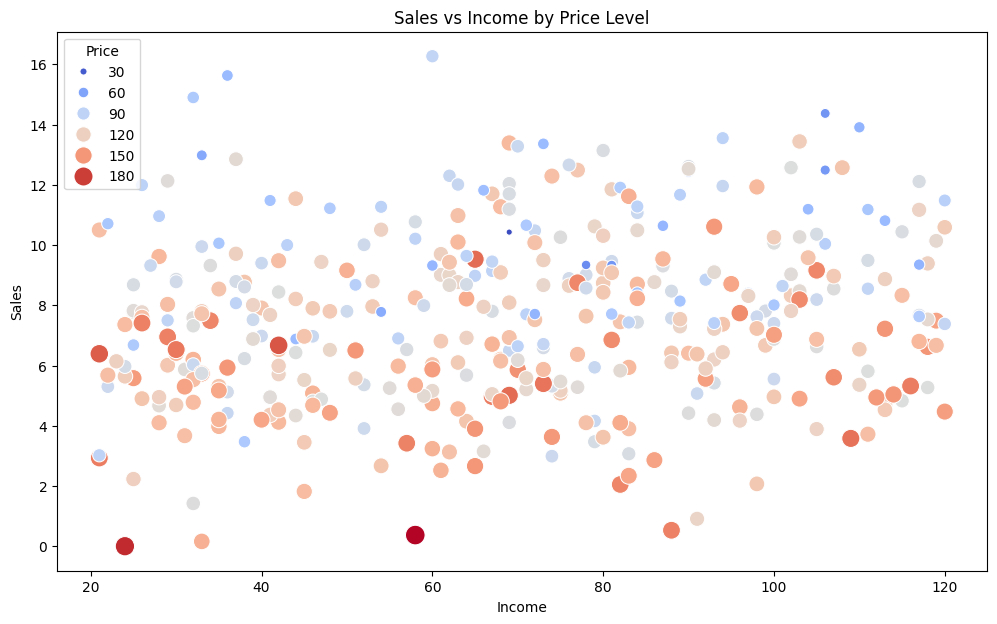

In [77]:
# 소득(Income)과 판매량(Sales)의 관계를 그리되, 가격(Price)의 높고 낮음을 색상(Hue)으로 표시
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Income', y='Sales', hue='Price', size='Price', 
                sizes=(20, 200), data=car, palette='coolwarm')

plt.title('Sales vs Income by Price Level')
plt.show()


count    400.000000
mean       6.635000
std        6.650364
min        0.000000
25%        0.000000
50%        5.000000
75%       12.000000
max       29.000000
Name: Advertising, dtype: float64


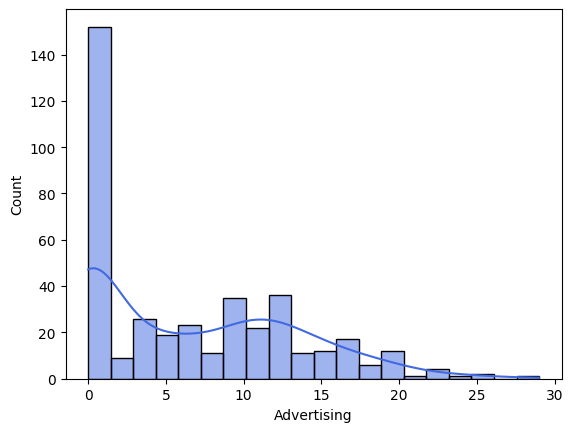

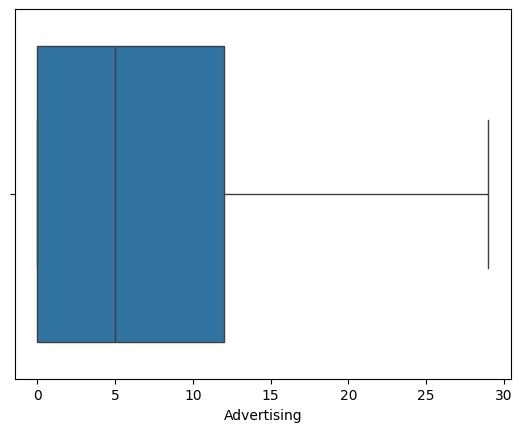

In [75]:
print(car['Advertising'].describe())

sns.histplot(car['Advertising'], kde=True, color='royalblue', bins=20)
plt.show()
sns.boxplot(x=car['Advertising'])
plt.show()

- 파악한 내용
    - 우리는 광고 예산을 거의 사용하지 않으며 일부 지역에만 5000~15000달러 수준의 광고료를 사용하고 있다.

- 추가로 파악하면 좋을 것
    - 광고료를 사용하는 지역이 실제로 유의미한 판매량을 내고 있는 지 파악. 
    - 위에서 파악한 분석 토대로 광고 예산을 사용하지 않는 지역의 판매량이 저조한 경우 광고 도입을 고려
- 분석 보완
    - 데이터 특이점: 이 데이터는 제로-인플레이션(Zero-Inflation) 특성이 강합니다. 광고비가 0인 데이터가 전체의 약 30~40%를 차지할 경우, 전체 데이터를 대상으로 하는 단순 선형 상관분석은 결과가 왜곡될 가능성이 큽니다.
    - 대안: 광고비를 쓰는 그룹($>0$)과 쓰지 않는 그룹($=0$)으로 **데이터를 분리(Stratification)**하여 각각의 판매량 평균에 대해 **T-검정(T-test)**을 수행함으로써 광고의 효과를 통계적으로 유의미하게 검증해야 합니다.

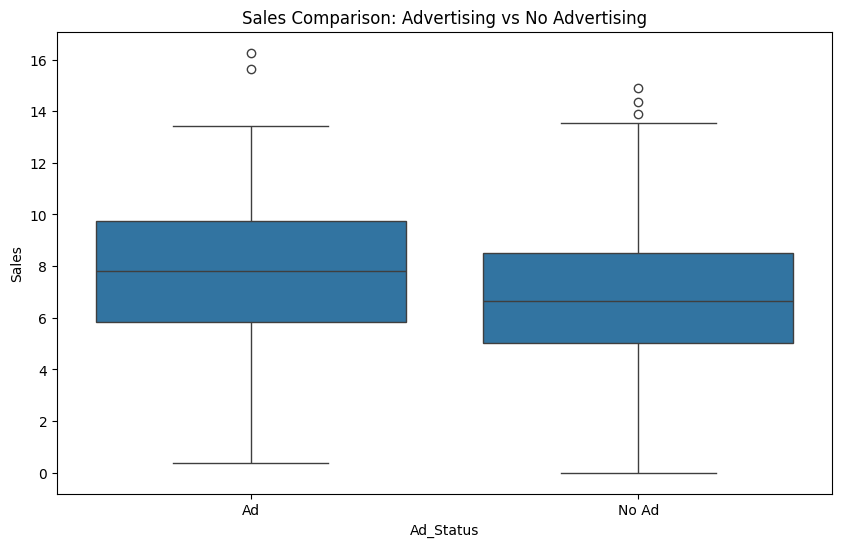

In [76]:
# 광고비 유무에 따른 새로운 파생변수 생성
car['Ad_Status'] = car['Advertising'].apply(lambda x: 'Ad' if x > 0 else 'No Ad')

# 그룹별 판매량 비교
plt.figure(figsize=(10, 6))
sns.boxplot(x='Ad_Status', y='Sales', data=car)
plt.title('Sales Comparison: Advertising vs No Advertising')
plt.show()


count    400.000000
mean       7.496325
std        2.824115
min        0.000000
25%        5.390000
50%        7.490000
75%        9.320000
max       16.270000
Name: Sales, dtype: float64


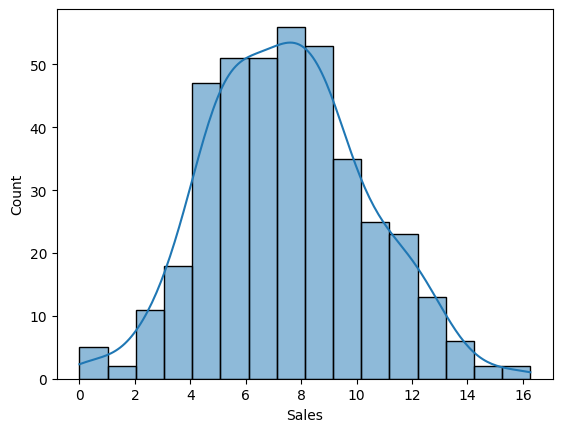

1. 왜도(Skewness): 0.186
2. 중심값 비교: 평균(7.50) vs 중앙값(7.49)


In [81]:
'''
1. [왜도 분석] 데이터의 비대칭성 증명 (예: Sales)
단순히 "중앙에 많이 몰려 있다"고 말하는 것보다, 
수치적으로 대칭성을 증명하는 방식입니다.'''
# [전] 기본적인 시각적 관찰
print(car['Sales'].describe())
sns.histplot(car['Sales'], kde=True)
plt.show()

# [후] 객관적 수치 기반 분석
mean_val = car['Sales'].mean()
median_val = car['Sales'].median()
skewness = car['Sales'].skew() # 왜도 계산

print(f"1. 왜도(Skewness): {skewness:.3f}") 
# 왜도가 -0.5 ~ 0.5 사이면 상당히 대칭적이라고 판단합니다.

print(f"2. 중심값 비교: 평균({mean_val:.2f}) vs 중앙값({median_val:.2f})")
# 두 값의 차이가 작을수록 이상치에 의한 왜곡이 적은 안정적인 분포임을 뜻합니다.


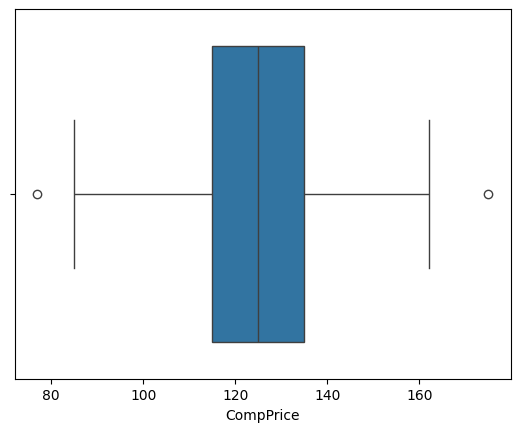

1. 이상치 경계 구간: 85.0 ~ 165.0
2. 이상치 개수: 2개
3. 이상치 비중: 0.50%


In [82]:
'''
2. [이상치 정량화] 시각적 지점을 수치로 확정 (예: CompPrice)
"이상치가 몇 개 있다"가 아니라,
"전체 데이터의 몇 %가 통계적 범위를 벗어났다"고 표현하는 방식입니다.'''
# [전] 박스플롯으로 이상치 확인
sns.boxplot(x=car['CompPrice'])
plt.show()

# [후] IQR 기반 이상치 정량적 분석
Q1 = car['CompPrice'].quantile(0.25)
Q3 = car['CompPrice'].quantile(0.75)
IQR = Q3 - Q1

# 경계값 계산
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# 이상치 데이터 추출
outliers = car[(car['CompPrice'] < lower_fence) | (car['CompPrice'] > upper_fence)]
outlier_pct = (len(outliers) / len(car)) * 100

print(f"1. 이상치 경계 구간: {lower_fence:.1f} ~ {upper_fence:.1f}")
print(f"2. 이상치 개수: {len(outliers)}개")
print(f"3. 이상치 비중: {outlier_pct:.2f}%")


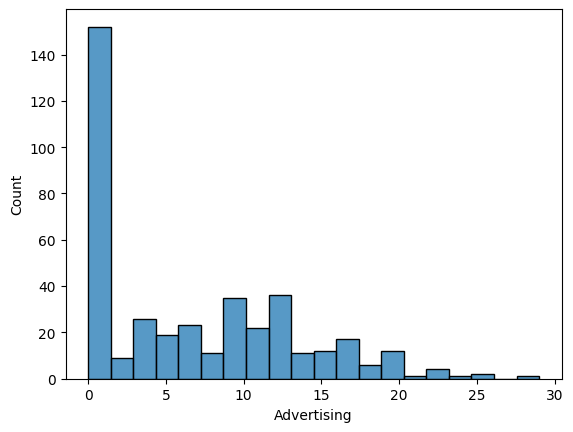

1. 광고비 미집행 지역 비중: 36.00%

2. [광고 집행 그룹]의 순수 기술통계량:
count    256.000000
mean      10.367188
std        5.509879
min        1.000000
25%        6.000000
50%       10.000000
75%       14.000000
max       29.000000
Name: Advertising, dtype: float64


In [83]:
'''[희소 데이터 처리] 특정 값에 쏠린 데이터 분석 (예: Advertising)
0이 많은 데이터에서 
0을 제외한 '실제 집행 그룹'의 순수 분포를 따로 보는 방식입니다.'''
# [전] 전체 데이터에 대한 분석
sns.histplot(car['Advertising'], bins=20)
plt.show()

# [후] 데이터 희소성(Sparsity) 및 활성 그룹 분석
zero_ads_pct = (car['Advertising'] == 0).mean() * 100
print(f"1. 광고비 미집행 지역 비중: {zero_ads_pct:.2f}%")

# 광고비가 0보다 큰 '실제 집행 그룹'만 따로 기술통계량 확인
active_ads = car[car['Advertising'] > 0]['Advertising']
print("\n2. [광고 집행 그룹]의 순수 기술통계량:")
print(active_ads.describe())

# 0을 제외하고 보았을 때 비로소 실제 광고비 집행의 '평균적 수준'이 객관적으로 드러납니다.


count    400.000000
mean     264.840000
std      147.376436
min       10.000000
25%      139.000000
50%      272.000000
75%      398.500000
max      509.000000
Name: Population, dtype: float64


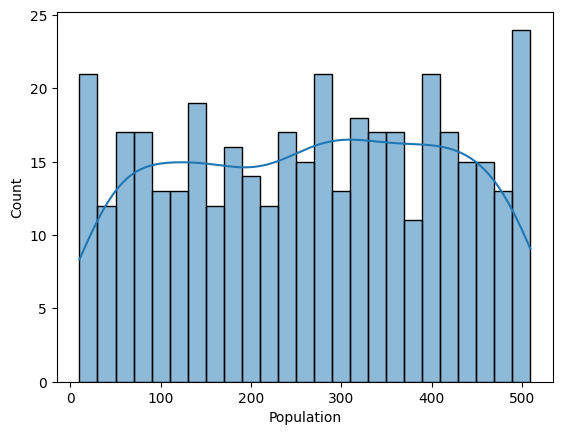

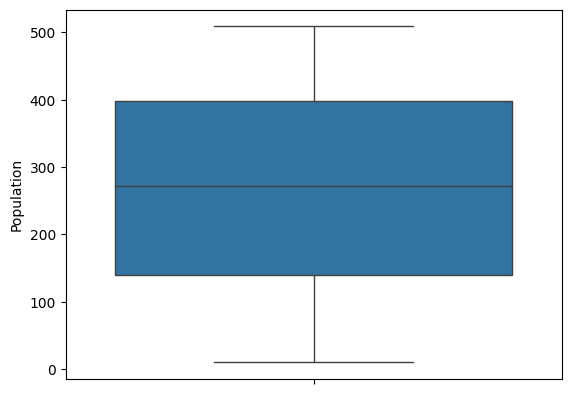

In [111]:
print(car['Population'].describe())
sns.histplot(car['Population'],bins=25, kde=True)
plt.show()
sns.boxplot(car['Population'])
plt.show()

- 파악한 내용
    - 너무 다양해서 특징을 잡기 힘들다.
    - 곧 데이터가 균등하다는 의미
- 추가로 파악하면 좋을 것
    - 무조건 다른 변수와의 상관계수를 파악해야 할 듯
    - 인구수 외에 다른 변수(예: 가격 경쟁력, 진열 위치)가 개입하고 있을 가능성이 매우 큼

count    400.000000
mean     115.795000
std       23.676664
min       24.000000
25%      100.000000
50%      117.000000
75%      131.000000
max      191.000000
Name: Price, dtype: float64


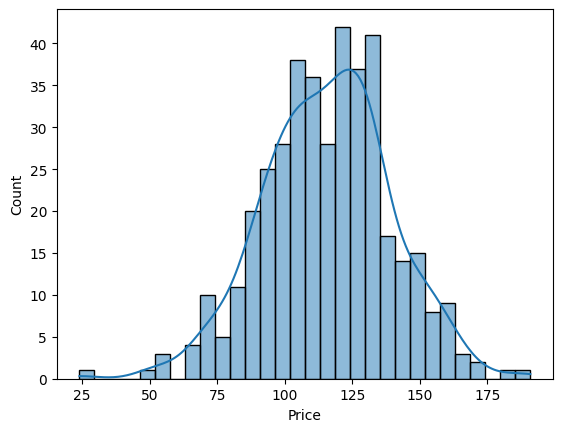

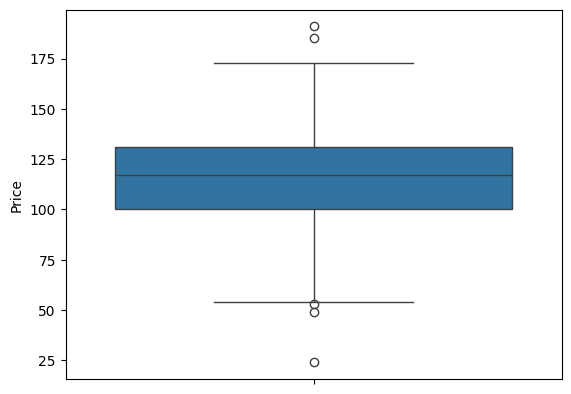

In [96]:
print(car['Price'].describe())
sns.histplot(car['Price'],bins=30, kde=True)
plt.show()
sns.boxplot(car['Price'])
plt.show()

- 파악한 내용
    - 100~130에 주로 가격을 형성하고 있지만 고가(150이상)과 저가(90이하) 판매 전략도 존재하고 있음
    - 단순히 "전략이 존재한다"라고 결론 내리기 전에, 이 이상치들이 전체 데이터에서 차지하는 **비중(%)**을 먼저 산출해 보시기 바랍니다. 만약 비중이 5% 미만이라면 이는 '전략적 분산'이라기보다 '특수 상황(재고 처리, 프리미엄 매장 등)'으로 해석하는 것이 더 객관적입니다
- 추가로 파악하면 좋을 것
    - 가격 별 판매량이 유의미한 지 확인
    - **지역 별 수입**과 경쟁사 가격과도 연관이 있는지 확인

count    400.000000
mean      53.322500
std       16.200297
min       25.000000
25%       39.750000
50%       54.500000
75%       66.000000
max       80.000000
Name: Age, dtype: float64


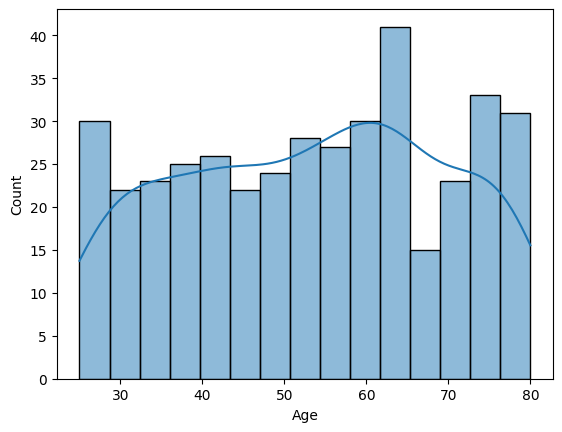

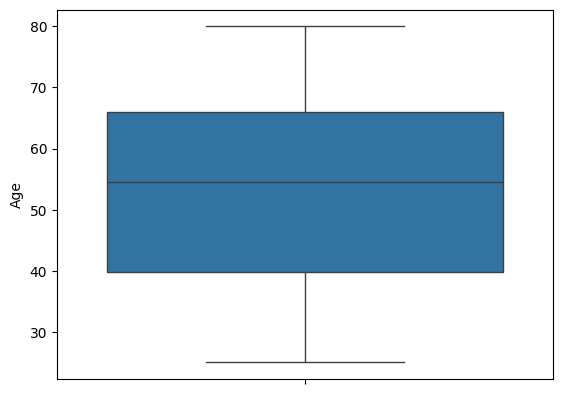

In [100]:
print(car['Age'].describe())
sns.histplot(car['Age'],bins=15, kde=True)
plt.show()
sns.boxplot(car['Age'])
plt.show()

- 파악한 내용
    - 연령대가 기본적으로 높음 (대부분 30대 이상)
    - 카 시트의 주요 수요층을 잘 노리고 있음
    - 특이점은 고연령층도 다수 존재함(50대 이상), 심지어 평균 연령이 50대 이상임
    - 주로 고령층의 손주를 위한 선물도 다수 할 것으로 생각해 볼 수 있음
- 추가로 파악하면 좋을 것
    - 지역 평균 소득이 높고 연령층이 높은 곳에서 판매량이 좋다면 위의 가설이 일치할 가능성 농후
    - 연령층 분포대로 판매량도 고령층 위주라면 관련 마케팅을 시행해도 좋아보임

Urban
Yes    282
No     118
Name: count, dtype: int64


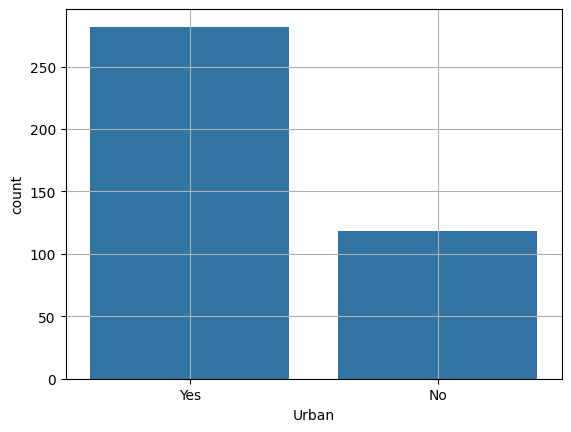

In [102]:
print(car['Urban'].value_counts())

sns.countplot(x=car['Urban'])
plt.grid()
plt.show()

- 파악한 내용
    - 도심 지역이 더 많음
- 추가로 파악하면 좋을 것

US
Yes    258
No     142
Name: count, dtype: int64


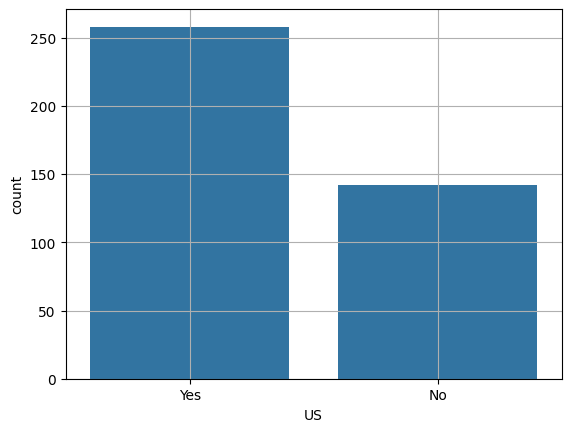

In [104]:
print(car['US'].value_counts())

sns.countplot(x=car['US'])
plt.grid()
plt.show()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64


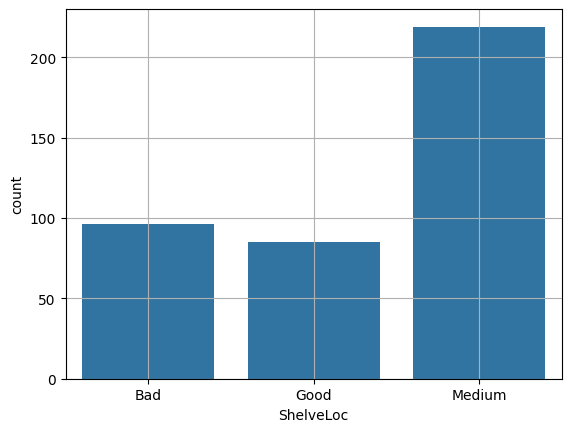

In [106]:
print(car['ShelveLoc'].value_counts())

sns.countplot(x=car['ShelveLoc'])
plt.grid()
plt.show()